# Exemple of Dirichlet boundary condition setting for the coarse enriched problem in monolithic approach



```{warning} 
For towscale monolithic approach we  want simple setting of dirichletBC object on coarse enriched space to be passed to `twoscale.core.generateCoarseManager` function. All  BC must be grouped into a single dirichletBC object. This object warp a field (Function) based on coarse enriched space. This function hold all 'g' values imposed by all fixed dofs. This object warp also all fixed dofs indexes expressed in coarse enriched space numbering.
```


Considering the following coarse mesh (rectangle of dimension B$\times$L along x $[0,B]$ and y $[-L/2,L/2]$) distributed on 4 process

In [1]:
import ipyparallel as ipp
cluster = ipp.Cluster(engines="mpi", n=4)
rc = cluster.start_and_connect_sync()
view=rc[:]

Starting 4 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>


  0%|          | 0/4 [00:00<?, ?engine/s]

In [2]:
%%px --local
from dolfinx import mesh
from dolfinx import fem
from dolfinx import plot
from dolfinx import default_scalar_type

from mpi4py import MPI
import pyvista as pv
from pyvista import Text
import test_util
import basix
import numpy as np


# setting
s=2
B=10.
L=20.
H=5.
# plots
pv.set_jupyter_backend("static")
pvopt={"show_edges":True, "show_scalar_bar":True}

Use Twoscale dolfinx implementation
[stdout:0] 
Use Twoscale dolfinx implementation
[stdout:1] 
Use Twoscale dolfinx implementation
[stdout:2] 
Use Twoscale dolfinx implementation
[stdout:3] 
Use Twoscale dolfinx implementation


In [3]:
%%px
nd=[s, 2*s]
domain= mesh.create_rectangle(MPI.COMM_WORLD,[[0.0, -L / 2], [B, L / 2]],nd,ghost_mode=mesh.GhostMode.none)
dim=domain.topology.dim
rank=domain.comm.rank

[output:0]

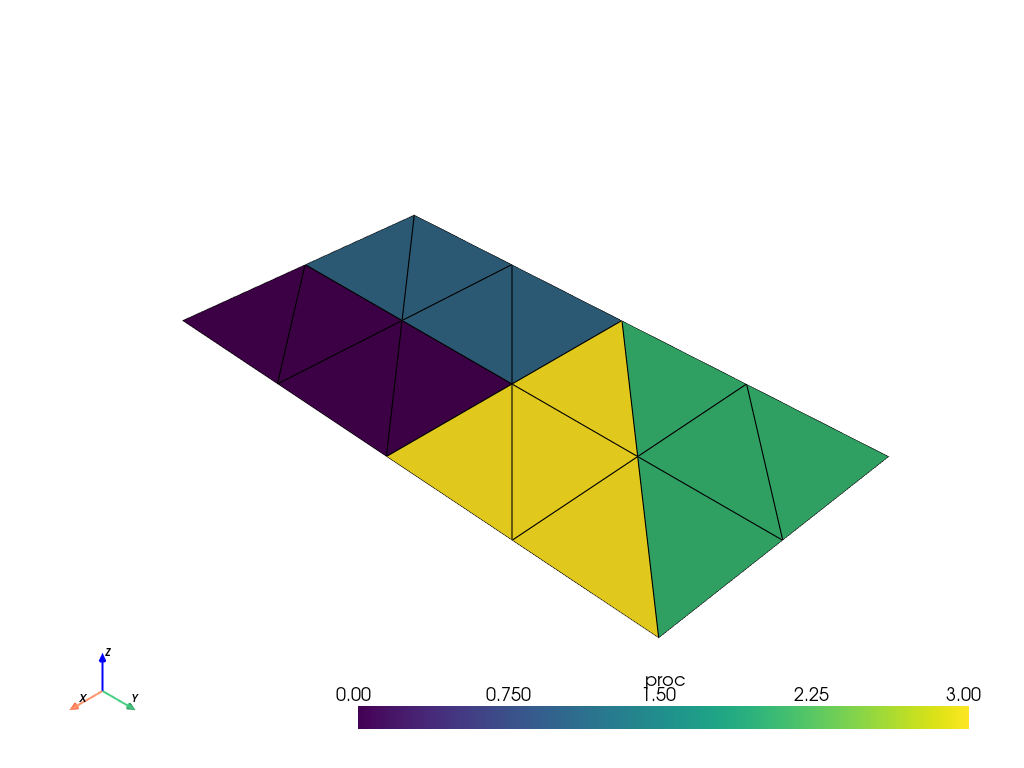

In [4]:
%%px
plt=pv.Plotter()
test_util.root_plot(domain,plt,pvopt)
plt.add_axes()
if rank == 0 :
    plt.show()



## Space 


The domain is the dolfinx mesh object create with create_xxx method thus by default it use Lagrange order 1 element.

The coarse enriched space is thus the mixed space based on use of 2 order 1 Lagrange spaces.


In [5]:
%%px
el_mixed = basix.ufl.mixed_element([domain.ufl_domain().ufl_coordinate_element(), domain.ufl_domain().ufl_coordinate_element()])
coarse_enriched_space = fem.functionspace(domain, el_mixed)


To see the different numbering behind this mixed space we extract the standard and enriched part as view (_) and as collapsed space


In [6]:
%%px
std_=coarse_enriched_space.sub(0)
std, std_to_mix=std_.collapse()
enr_=coarse_enriched_space.sub(1)
enr, enr_to_mix=enr_.collapse()



In this case std and enr are identical (same numbering/index map). For subspace std_, enr_, they also have same numbering as coarse_enriched_space regarding index map but they are related only to their respective sub space dofs.Regarding blocking std,enr are using dim block size and std_,enr_,coarse_enriched_space use 1 block size.

The following display shows at each vertex a string  starting by a letter K followed by a set of groupes of the form L:XX(YY),XX(YY),... where:
* K is l for a dof owned by this proc and r for a dof owned remotely by another proc (owned/ghost mechanism)
* L a letter indicating if we talk of std dof (s), coarse_enriched_space dof related to standard subspace std_ (cs) or coarse_enriched_space dofs related to enriched subspace enr_ dof (ce)
* XX is the  global number of L dof(s) (bloc number for std) associated to the vertex
* YY is the  local number of L dof(s) (bloc number for std) associated to the vertex


[output:0]

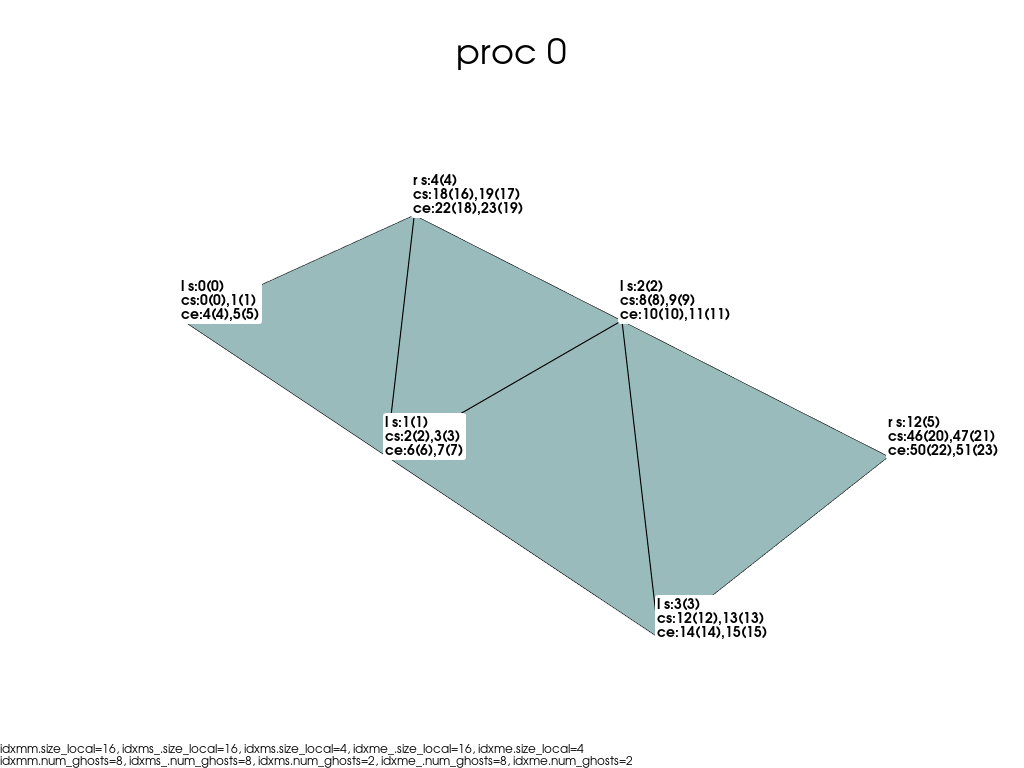

[output:3]

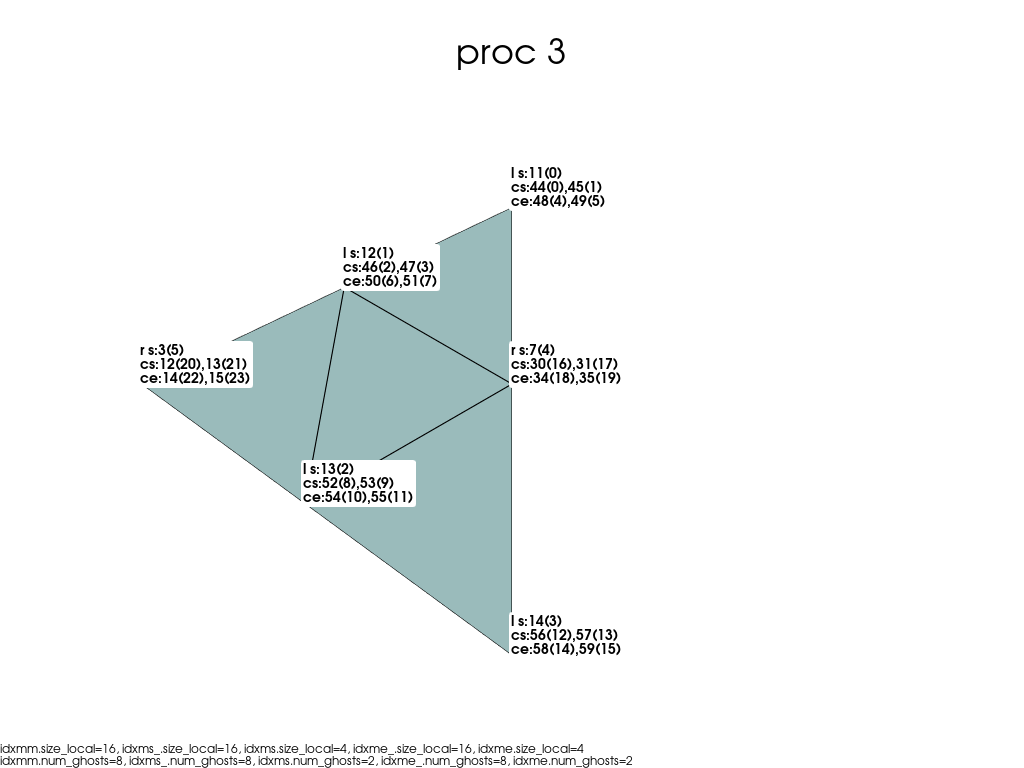

[output:2]

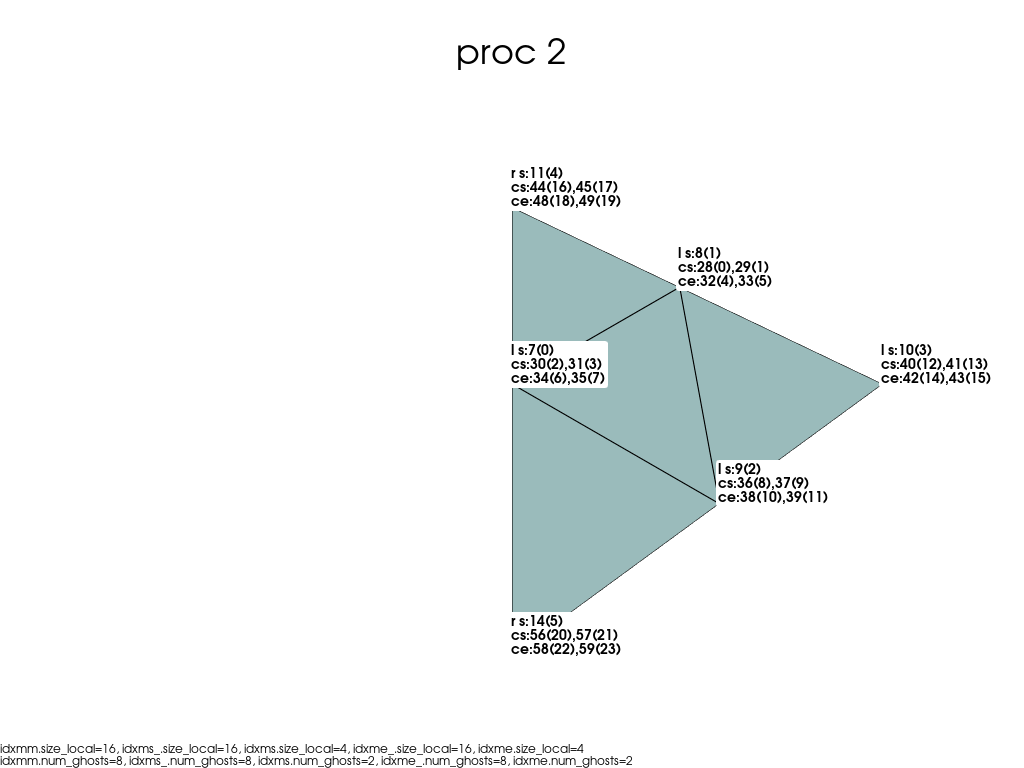

[output:1]

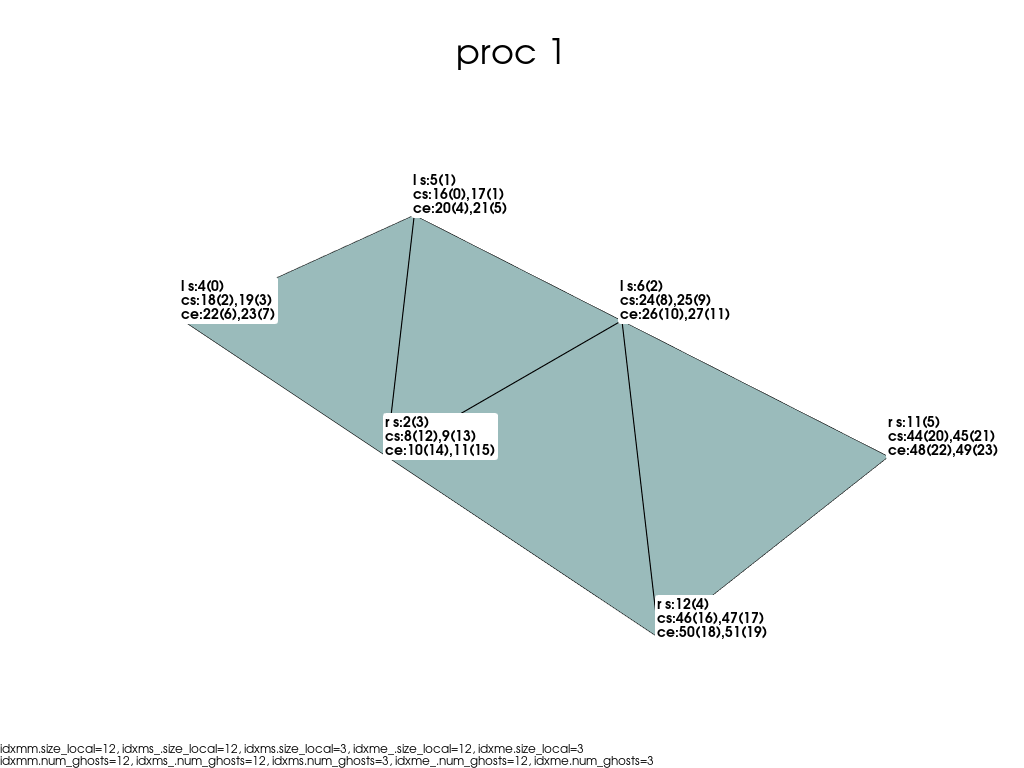

In [7]:
%%px
idxmm=coarse_enriched_space.dofmap.index_map
idxms_=std_.dofmap.index_map
idxme_=enr_.dofmap.index_map
idxms=std.dofmap.index_map
idxme=enr.dofmap.index_map

#show sizes
sizes=Text(text=f"{idxmm.size_local=}, {idxms_.size_local=}, {idxms.size_local=}, {idxme_.size_local=}, {idxme.size_local=}\n{idxmm.num_ghosts=}, {idxms_.num_ghosts=}, {idxms.num_ghosts=}, {idxme_.num_ghosts=}, {idxme.num_ghosts=}")
sizes.prop.font_size=12

# only way to get coordinates: coarse_enriched_space,std_ and enr_ can't give these informations.
# note that enr gives the same.
xl=std.tabulate_dof_coordinates()

# bs
bss=std.dofmap.index_map_bs
bsm=coarse_enriched_space.dofmap.index_map_bs

#labels
loc_labels=np.array(range(0,idxms.size_local+idxms.num_ghosts))
glob_labels_loc=np.array(range(0,idxms.size_local))
glob_labels_loc=idxms.local_to_global(glob_labels_loc)
glob_labels=np.concatenate((glob_labels_loc,np.array(idxms.ghosts)))
loc_labelm=np.array(range(0,idxmm.size_local+idxmm.num_ghosts))
glob_labelm_loc=np.array(range(0,idxmm.size_local))
glob_labelm_loc=idxmm.local_to_global(glob_labelm_loc)
glob_labelm=np.concatenate((glob_labelm_loc,np.array(idxmm.ghosts)))
labels=[]
for i in loc_labels:
    if i <idxms.size_local:
        s="l "
    else:
        s="r "
    s+="s:{}({})".format(glob_labels[i],i)
    s+="\ncs:{}({})".format(glob_labelm[std_to_mix[0][i*bss]],loc_labelm[std_to_mix[0][i*bss]])
    for b in range(1,bss):
        s+=",{}({})".format(glob_labelm[std_to_mix[0][i*bss+b]],loc_labelm[std_to_mix[0][i*bss+b]])
    s+="\nce:{}({})".format(glob_labelm[enr_to_mix[0][i*bss]],loc_labelm[enr_to_mix[0][i*bss]])
    for b in range(1,bss):
        s+=",{}({})".format(glob_labelm[enr_to_mix[0][i*bss+b]],loc_labelm[enr_to_mix[0][i*bss+b]])
    labels.append(s)
    
# plot
plt=pv.Plotter()
ccells, ctypes, cx = plot.vtk_mesh(domain)
cgrid = pv.UnstructuredGrid(ccells, ctypes, cx)
plt.add_mesh(cgrid,**pvopt)
plt.add_point_labels(xl, labels, point_size=2, font_size=14,shape_color='white')
plt.add_title("proc {}".format(MPI.COMM_WORLD.Get_rank()),font_size=14)
plt.add_actor(sizes)
plt.show()


## First case


* std dofs at nodes at x=0 are clamped (all components set to 0)
* std dofs at nodes at X=B are with a impose field value for all components following:
    * $imp_x=(2\times\frac{y}{L})^2$
    * $imp_y=+/-1$ at $y=+/-L/2$

First select nodes of the domain for those BC:

In [8]:
%%px
clamp_std_nodes=mesh.locate_entities(domain, 0, lambda x: np.isclose(x[0], 0.))
imp_std_nodes=mesh.locate_entities(domain, 0, lambda x: np.isclose(x[0], B))
imp_corner_m_std_nodes=mesh.locate_entities(domain, 0, lambda x: np.logical_and(np.isclose(x[0], B),np.isclose(x[1],-L/2)))
imp_corner_p_std_nodes=mesh.locate_entities(domain, 0, lambda x: np.logical_and(np.isclose(x[0], B),np.isclose(x[1],L/2)))



The function locate_dofs_topological that is used below needs to use the adjancy of the mesh connecting all dim entities to nodes thus domain topology must be updated.

In [9]:
%%px
domain.topology.create_connectivity(0,dim)


Now the function locate_dofs_topological can be used to get dofs (in local numbering) related to nodes selected for various BC. 
For most of the clamped dofs its simple as the final BC use a constante 0 for all componnents so we can use directely the view/sub field (_):

In [10]:
%%px
clamp_std_dofs=fem.locate_dofs_topological(std_,0,clamp_std_nodes)


And the associated boundary condition values can be stored in a field based on mixed space with null values that will be used for dirichletBC construction:

In [11]:
%%px
all_BC_values=fem.Function(coarse_enriched_space)


For imposed +/-1 values at corners again we passe by a sub space of std as we area only intrested by y component: 

In [12]:
%%px
imp_corner_m_imp_dof_y=fem.locate_dofs_topological(std.sub(1),0,imp_corner_m_std_nodes)
imp_corner_p_imp_dof_y=fem.locate_dofs_topological(std.sub(1),0,imp_corner_p_std_nodes)


and we must translated std dofs in coarse_enriched_space via std_to_mix corespondance.

In [13]:
%%px
std_to_mix_np=np.asarray(std_to_mix[0])
imp_corner_m_imp_dof=std_to_mix_np[imp_corner_m_imp_dof_y]
imp_corner_p_imp_dof=std_to_mix_np[imp_corner_p_imp_dof_y]


In this case we must set +/-1 value to identified dof in imposed field:

In [14]:
%%px
all_BC_values.x.array[imp_corner_m_imp_dof]=-1
all_BC_values.x.array[imp_corner_p_imp_dof]=1    


For imposed  values in x direction along edge at B  again we passe by a sub space of std as we area only intrested by x component: 

In [15]:
%%px
imp_std_dof_x=fem.locate_dofs_topological(std.sub(0),0,imp_std_nodes)


and we must translated std dofs in coarse_enriched_space via std_to_mix corespondance.

In [16]:
%%px
imp_std_dof=std_to_mix_np[imp_std_dof_x]


In this case we must set  values to identified dofs in imposed field following   $imp_x=(2\times\frac{y}{L})^2$ equation. Compare to usual FEniCSx usage of passing by an interpolation function we are going to set dofs values directly.  This is possible because space in ours case are simple lagrange order 1 discretisation. But we needs coordinates to do the computation. Using directely coordinate of the mesh:

In [17]:
%%px
xc=domain.geometry.x
all_BC_values.x.array[imp_std_dof]=np.pow(2*xc[imp_std_nodes,1]/L,2.)




```{note}
Here we use the fact that the node set used to collect dofs gives throught locate_dofs_topological the dofs in the same order as the nodes(as there is 1 to 1 correspondance for lagrange space).

```{admonition} alternatively tabulate dof coordinates can be used
:class: tip, dropdown
The only way to get tabulate dof coordinate is to use std space as coarse_enriched_space and std_ can't give them. The given tabulate dof  coordinates xs if used  give per nodes supporting dof coordinate. Thus dofs selection have to be "blocked" (divide by block size) to be able to filter xs correctelly
```python
xs=std.tabulate_dof_coordinates()
imp_std_dof_x_b=np.floor_divide(imp_std_dof_x,std.sub(0).dofmap.index_map_bs)
all_BC_values.x.array[imp_std_dof]=np.pow(2*xs[imp_std_dof_x_b,1]/L,2.)
```

The dofs selections are finaly strored in a all_BC_dof array that needs to be sorted (to obtaines correct indices order in dirichlet object)

In [18]:
%%px
all_BC_dof=np.concat((clamp_std_dofs,imp_corner_m_imp_dof,imp_corner_p_imp_dof,imp_std_dof))
all_BC_dof.sort()

In [19]:
%%px
print(f"\nimp_std_dof={imp_std_dof.tolist()}\nimp_corner_p_imp_dof={imp_corner_p_imp_dof.tolist()}\nimp_corner_m_imp_dof={imp_corner_m_imp_dof.tolist()}\nclamp_std_dofs={clamp_std_dofs.tolist()}\nall_BC_dof={all_BC_dof.tolist()}")


[stdout:0] 
imp_std_dof=[0, 2, 12]
imp_corner_p_imp_dof=[]
imp_corner_m_imp_dof=[1]
clamp_std_dofs=[]
all_BC_dof=[0, 1, 2, 12]


[stdout:1] 
imp_std_dof=[]
imp_corner_p_imp_dof=[]
imp_corner_m_imp_dof=[]
clamp_std_dofs=[0, 1, 8, 9, 20, 21]
all_BC_dof=[0, 1, 8, 9, 20, 21]


[stdout:2] 
imp_std_dof=[20]
imp_corner_p_imp_dof=[21]
imp_corner_m_imp_dof=[]
clamp_std_dofs=[0, 1, 12, 13, 16, 17]
all_BC_dof=[0, 1, 12, 13, 16, 17, 20, 21]


[stdout:3] 
imp_std_dof=[8, 12, 20]
imp_corner_p_imp_dof=[13]
imp_corner_m_imp_dof=[]
clamp_std_dofs=[0, 1]
all_BC_dof=[0, 1, 8, 12, 13, 20]



It is now possible to create the dirchletBC object expected by the TwoScale functions using dirichletbs function with constructed all_BC_values and all_BC_dof

In [20]:
%%px
BC=fem.dirichletbc(all_BC_values,all_BC_dof)

In [21]:
%%px
print(f"BC:\nencapsulated dofs:{BC.dof_indices()}\nencapsulated values:{BC.g.x.array}")


[stdout:1] BC:
encapsulated dofs:(array([ 0,  1,  8,  9, 20, 21], dtype=int32), 4)
encapsulated values:[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


[stdout:0] BC:
encapsulated dofs:(array([ 0,  1,  2, 12], dtype=int32), 4)
encapsulated values:[ 1.   -1.    0.25  0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]


[stdout:2] BC:
encapsulated dofs:(array([ 0,  1, 12, 13, 16, 17, 20, 21], dtype=int32), 4)
encapsulated values:[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.]


[stdout:3] BC:
encapsulated dofs:(array([ 0,  1,  8, 12, 13, 20], dtype=int32), 5)
encapsulated values:[0.   0.   0.   0.   0.   0.   0.   0.   0.25 0.   0.   0.   1.   1.
 0.   0.   0.   0.   0.   0.   0.25 0.   0.   0.  ]



The imposed non null values to std dofs can be visualized as follow (with a display scale factor of 2):

[output:0]

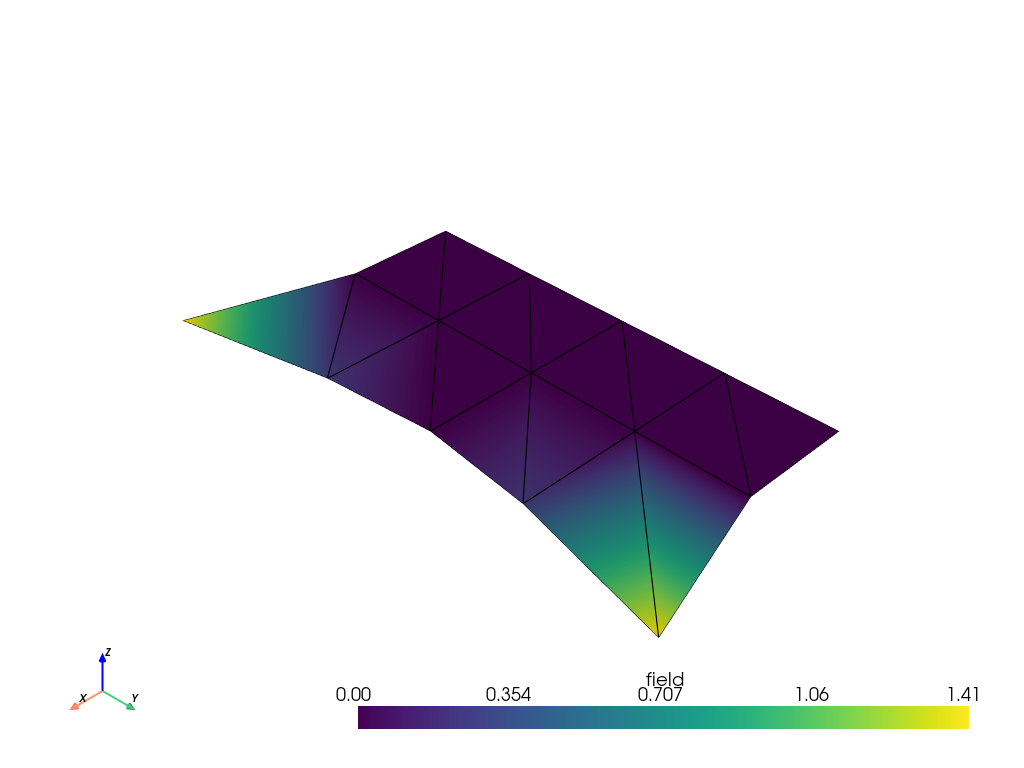

In [22]:
%%px
plt=pv.Plotter()
visu_std=fem.Function(std)
visu_std.x.array[imp_std_dof_x]=all_BC_values.x.array[imp_std_dof]
visu_std.x.array[imp_corner_m_imp_dof_y]=all_BC_values.x.array[imp_corner_m_imp_dof]
visu_std.x.array[imp_corner_p_imp_dof_y]=all_BC_values.x.array[imp_corner_p_imp_dof]
test_util.root_plot_field(domain,plt,pvopt,std,visu_std,2)
plt.add_axes()
if rank == 0 :
    plt.show()

